# Flash Point Modeling using DeepONets

This notebook evaluates the use of Deep Operator Networks (DeepONets) for flash point (FP) prediction and compares their performance with a standard feedforward neural network (FNN) baseline. To keep the comparison as fair as possible, both models are trained on the same experimental dataset using similar architectural settings, while still respecting the structural differences between a conventional FNN and a DeepONet.

The notebook is organized into the following stages:

- **Dependencies:** import the required libraries and define the execution setup.
- **Model Architectures:** implement the FNN and DeepONet models used in the study.
- **Data Loading:** read the experimental dataset and filter the subset used for modeling.
- **Training Functions:** implement the functions used to train the FNN and DeepONet models.
- **Hyperparameter Optimization:** define the Optuna objective functions for both FNN and DeepONets models, aiming to find the optimal learning rate.
- **Models Training:** prepare the input features, apply 5-fold cross-validation, train both models, and track fold-level performance.
- **Models Benchmarking:** aggregate the results across folds to compare the predictive performance of both approaches.

## Dependencies

In [1]:
# Imports
import copy
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from torchmetrics import (
    MeanAbsoluteError,
    MeanSquaredError,
    MeanAbsolutePercentageError,
    R2Score,
)

# Initial setup
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10000
EARLY_STOPPING_PATIENCE = 1000
EARLY_STOPPING_MIN_DELTA = 1e-4
DATA_PATH = Path("../data/public")

c:\Users\mauri\anaconda3\envs\sciml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Architectures

In [2]:
class FNN(nn.Module):
    """
    Standard feedforward neural network
    """

    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        hidden_width: int = 14,
        n_layers: int = 3,
        activation: type[nn.Module] = nn.ReLU,
    ) -> None:
        super().__init__()
        layers = []
        current_dim = input_dim
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(current_dim, hidden_width))
            layers.append(activation())
            current_dim = hidden_width
        layers.append(nn.Linear(current_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class DeepONet(nn.Module):
    """
    Standard DeepONet
    """

    def __init__(
        self,
        branch_dim: int,
        trunk_dim: int,
        output_dim: int = 1,
        hidden_width: int = 14,
        n_layers: int = 3,
    ) -> None:
        super().__init__()
        self.branch = FNN(branch_dim, output_dim, hidden_width, n_layers)
        self.trunk = FNN(trunk_dim, output_dim, hidden_width, n_layers)
        self.bias = nn.Parameter(torch.zeros(output_dim))

    def forward(
        self, branch_input: torch.Tensor, trunk_input: torch.Tensor
    ) -> torch.Tensor:
        B = self.branch(branch_input)
        T = self.trunk(trunk_input)

        output = torch.sum(B * T, dim=-1, keepdim=True) + self.bias

        return output

## Data Loading

In [3]:
# Reading the data into a DataFrame
data = pd.read_csv(DATA_PATH / "raw" / "fp_experimental_data.csv")

display(data)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method,FP
0,ethyl laurate,NaN,1.000,0.000,228.37,-1.450000,0,402.30
1,ethanol,octane,0.005,0.995,113.86,7.575678,1,286.15
2,ethanol,octane,0.010,0.990,113.49,7.593094,1,283.45
3,ethanol,octane,0.020,0.980,112.75,7.627042,1,281.95
4,ethanol,octane,0.030,0.970,112.00,7.659875,1,280.75
...,...,...,...,...,...,...,...,...
361,octane,NaN,1.000,0.000,114.23,7.557953,1,287.65
362,ethanol,NaN,1.000,0.000,40.07,9.078902,1,286.15
363,methyl butyrate,NaN,1.000,0.000,102.13,4.172583,1,284.55
364,propyl acetate,NaN,1.000,0.000,102.13,3.902982,1,284.55


In [4]:
# Select Method 0 (ASTM D6450) rows and keep relevant columns
filtered_data = data.loc[
    data["Method"] == 0, ["x_1", "MM", "lnPvap", "FP"]
].reset_index(drop=True)

display(filtered_data)

,x_1,MM,lnPvap,FP
0,1.0,228.37,-1.45,402.3
1,0.1,183.49,2.44,370.6
2,0.1,208.73,1.87,384.6
3,0.1,233.98,1.79,393.5
4,0.1,259.23,1.78,396.9
...,...,...,...,...
300,1.0,308.50,-7.58,453.1
301,1.0,200.32,0.82,379.5
302,1.0,40.07,9.08,288.5
303,1.0,170.33,2.89,354.4


In [5]:
# Define features for each model
fnn_features = filtered_data[["MM", "lnPvap"]].values
branch_features = filtered_data[["x_1", "lnPvap"]].values
trunk_features = filtered_data[["x_1", "MM"]].values
fp_values = filtered_data["FP"].values

## Training Functions

In [6]:
def fit_transform_except_x1(
    scaler: StandardScaler, features: np.ndarray, x1_column_index: int = 0
) -> np.ndarray:
    """Fit a scaler to non-x_1 columns and return x_1 unchanged."""
    transformed_features = features.copy()
    scaled_columns = [
        column_idx
        for column_idx in range(features.shape[1])
        if column_idx != x1_column_index
    ]
    transformed_features[:, scaled_columns] = scaler.fit_transform(
        features[:, scaled_columns]
    )
    return transformed_features


def transform_except_x1(
    scaler: StandardScaler, features: np.ndarray, x1_column_index: int = 0
) -> np.ndarray:
    """Apply a fitted scaler to non-x_1 columns and return x_1 unchanged."""
    transformed_features = features.copy()
    scaled_columns = [
        column_idx
        for column_idx in range(features.shape[1])
        if column_idx != x1_column_index
    ]
    transformed_features[:, scaled_columns] = scaler.transform(
        features[:, scaled_columns]
    )
    return transformed_features


def compute_metrics(
    predictions: torch.Tensor, targets: torch.Tensor
) -> dict[str, float]:
    """Compute regression metrics using the torchmetrics classes imported above."""
    metric_objects = {
        "mae (K)": MeanAbsoluteError().to(DEVICE),
        "rmse (K)": MeanSquaredError(squared=False).to(DEVICE),
        "mape": MeanAbsolutePercentageError().to(DEVICE),
        "r2": R2Score().to(DEVICE),
    }

    return {
        name: metric(predictions, targets).detach().cpu().item()
        for name, metric in metric_objects.items()
    }


def plot_fold_results(
    model_name: str,
    fold_idx: int,
    train_losses: list[float],
    val_losses: list[float],
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> None:
    """Plot loss evolution and experimental vs predicted FP values for a fold."""
    y_true = targets.detach().cpu().numpy().ravel()
    y_pred = predictions.detach().cpu().numpy().ravel()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_losses, label="Train loss")
    axes[0].plot(val_losses, label="Validation loss")
    axes[0].set_title(f"{model_name} - Fold {fold_idx} loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE loss")
    axes[0].legend()

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    axes[1].scatter(y_true, y_pred, alpha=0.8)
    axes[1].plot([min_value, max_value], [min_value, max_value], "k--")
    axes[1].set_title(f"{model_name} - Fold {fold_idx}")
    axes[1].set_xlabel("Experimental FP")
    axes[1].set_ylabel("Predicted FP")

    plt.tight_layout()
    plt.show()


def train_fnn_fold(
    model: FNN,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    x_val: torch.Tensor,
    y_val: torch.Tensor,
    lr: float = 1e-3,
    patience: int = EARLY_STOPPING_PATIENCE,
    min_delta: float = EARLY_STOPPING_MIN_DELTA,
) -> tuple[list[float], list[float], torch.Tensor]:
    """Train the FNN for one fold and return loss histories and best predictions."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_without_improvement = 0

    for _ in range(EPOCHS):
        model.train()
        train_predictions = model(x_train)
        train_loss = loss_fn(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val)
            val_loss = loss_fn(val_predictions, y_val)

        train_losses.append(train_loss.detach().cpu().item())
        current_val_loss = val_loss.detach().cpu().item()
        val_losses.append(current_val_loss)

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        val_predictions = model(x_val)

    return train_losses, val_losses, val_predictions


def train_deeponet_fold(
    model: DeepONet,
    branch_train: torch.Tensor,
    trunk_train: torch.Tensor,
    y_train: torch.Tensor,
    branch_val: torch.Tensor,
    trunk_val: torch.Tensor,
    y_val: torch.Tensor,
    lr: float = 1e-3,
    patience: int = EARLY_STOPPING_PATIENCE,
    min_delta: float = EARLY_STOPPING_MIN_DELTA,
) -> tuple[list[float], list[float], torch.Tensor]:
    """Train the DeepONet for one fold and return loss histories and best predictions."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state_dict = None
    epochs_without_improvement = 0

    for _ in range(EPOCHS):
        model.train()
        train_predictions = model(branch_train, trunk_train)
        train_loss = loss_fn(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(branch_val, trunk_val)
            val_loss = loss_fn(val_predictions, y_val)

        train_losses.append(train_loss.detach().cpu().item())
        current_val_loss = val_loss.detach().cpu().item()
        val_losses.append(current_val_loss)

        if current_val_loss < best_val_loss - min_delta:
            best_val_loss = current_val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        val_predictions = model(branch_val, trunk_val)

    return train_losses, val_losses, val_predictions

## Hyperparameter Optimization

In [7]:
def objective_fnn(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    folds = 5
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    fold_rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(fnn_features), start=1):
        fnn_scaler = StandardScaler()

        fnn_train = fnn_scaler.fit_transform(fnn_features[train_idx])
        fnn_val = fnn_scaler.transform(fnn_features[val_idx])

        fnn_train_tensor = torch.tensor(fnn_train, dtype=torch.float32).to(DEVICE)
        fnn_val_tensor = torch.tensor(fnn_val, dtype=torch.float32).to(DEVICE)

        y_train_tensor = torch.tensor(
            fp_values[train_idx], dtype=torch.float32
        ).unsqueeze(1).to(DEVICE)

        y_val_tensor = torch.tensor(
            fp_values[val_idx], dtype=torch.float32
        ).unsqueeze(1).to(DEVICE)

        model = FNN(
            input_dim=fnn_train_tensor.shape[1],
            output_dim=1
        ).to(DEVICE)

        train_losses, val_losses, val_predictions = train_fnn_fold(
            model,
            fnn_train_tensor,
            y_train_tensor,
            fnn_val_tensor,
            y_val_tensor,
            lr=lr,
        )

        metrics = compute_metrics(val_predictions, y_val_tensor)
        fold_rmses.append(metrics["rmse (K)"])

    return np.mean(fold_rmses)

In [8]:
def objective_deeponet(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    folds = 5
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    fold_rmses = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(fnn_features), start=1):
        branch_scaler = StandardScaler()
        trunk_scaler = StandardScaler()

        branch_train = fit_transform_except_x1(branch_scaler, branch_features[train_idx])
        branch_val = transform_except_x1(branch_scaler, branch_features[val_idx])

        trunk_train = fit_transform_except_x1(trunk_scaler, trunk_features[train_idx])
        trunk_val = transform_except_x1(trunk_scaler, trunk_features[val_idx])

        branch_train_tensor = torch.tensor(branch_train, dtype=torch.float32).to(DEVICE)
        branch_val_tensor = torch.tensor(branch_val, dtype=torch.float32).to(DEVICE)

        trunk_train_tensor = torch.tensor(trunk_train, dtype=torch.float32).to(DEVICE)
        trunk_val_tensor = torch.tensor(trunk_val, dtype=torch.float32).to(DEVICE)

        y_train_tensor = torch.tensor(
            fp_values[train_idx], dtype=torch.float32
        ).unsqueeze(1).to(DEVICE)

        y_val_tensor = torch.tensor(
            fp_values[val_idx], dtype=torch.float32
        ).unsqueeze(1).to(DEVICE)

        model = DeepONet(
            branch_dim=branch_train_tensor.shape[1],
            trunk_dim=trunk_train_tensor.shape[1],
            output_dim=1,
        ).to(DEVICE)

        train_losses, val_losses, val_predictions = train_deeponet_fold(
            model,
            branch_train_tensor,
            trunk_train_tensor,
            y_train_tensor,
            branch_val_tensor,
            trunk_val_tensor,
            y_val_tensor,
            lr=lr,
        )

        metrics = compute_metrics(val_predictions, y_val_tensor)
        fold_rmses.append(metrics["rmse (K)"])

    return np.mean(fold_rmses)

In [9]:
study_fnn = optuna.create_study(direction="minimize")
study_fnn.optimize(objective_fnn, n_trials=25)

study_deeponet = optuna.create_study(direction="minimize")
study_deeponet.optimize(objective_deeponet, n_trials=25)

print("Best FNN:")
print(study_fnn.best_params)
print(study_fnn.best_value)

print("Best DeepONet:")
print(study_deeponet.best_params)
print(study_deeponet.best_value)

[I 2026-05-21 14:28:06,030] A new study created in memory with name: no-name-32d50378-0bbf-4424-ba24-1d7411a0a01a
[I 2026-05-21 14:29:36,718] Trial 0 finished with value: 7.280260181427002 and parameters: {'lr': 0.008095516638602201}. Best is trial 0 with value: 7.280260181427002.
[I 2026-05-21 14:33:16,216] Trial 1 finished with value: 379.09791259765626 and parameters: {'lr': 1.9078528268963624e-05}. Best is trial 0 with value: 7.280260181427002.
[I 2026-05-21 14:37:55,373] Trial 2 finished with value: 373.9629699707031 and parameters: {'lr': 2.4269940457647093e-05}. Best is trial 0 with value: 7.280260181427002.
[I 2026-05-21 14:42:18,242] Trial 3 finished with value: 6.211937618255615 and parameters: {'lr': 0.0004408715881629611}. Best is trial 3 with value: 6.211937618255615.
[I 2026-05-21 14:47:18,187] Trial 4 finished with value: 380.8096008300781 and parameters: {'lr': 1.134317511371718e-05}. Best is trial 3 with value: 6.211937618255615.
[I 2026-05-21 14:52:38,486] Trial 5 fin

Best FNN:
{'lr': 0.0014276567560015743}
5.118398666381836
Best DeepONet:
{'lr': 0.0023435127465847253}
3.932019090652466


## Model Training

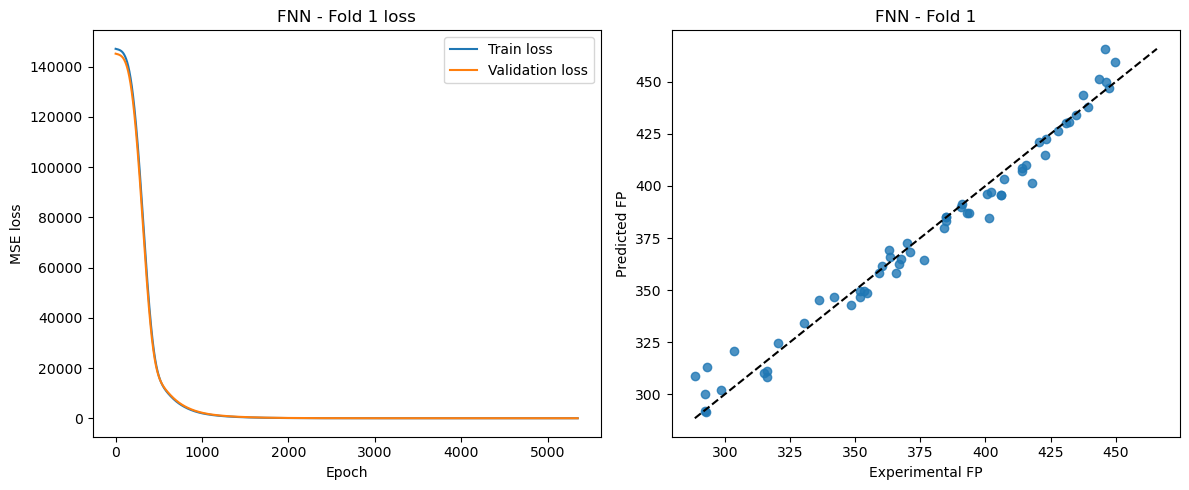

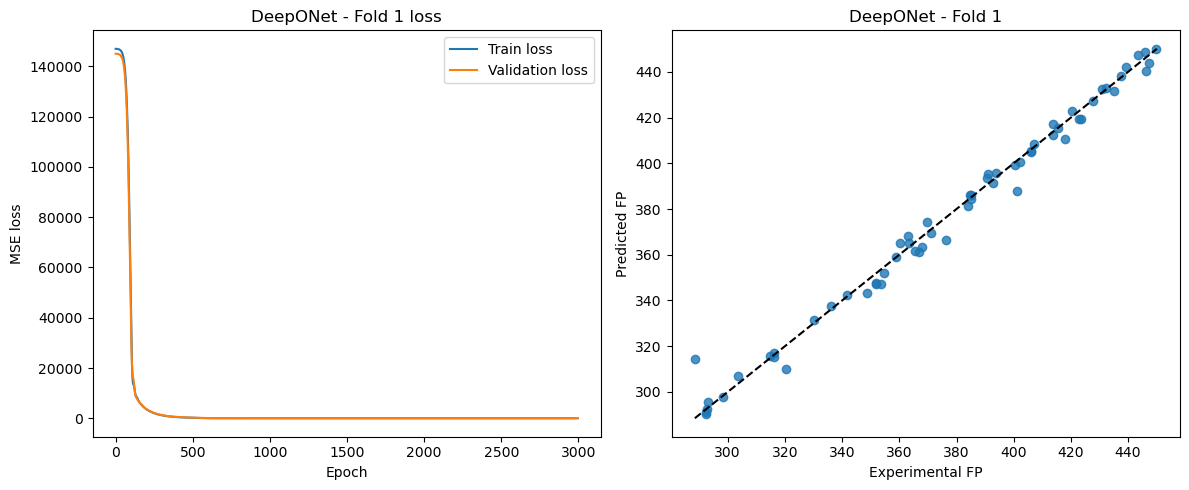

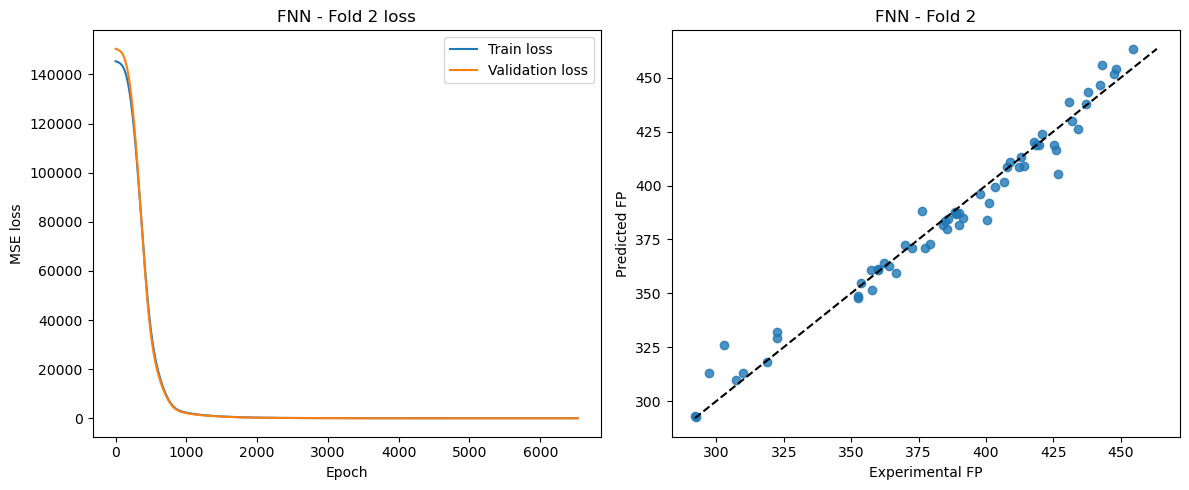

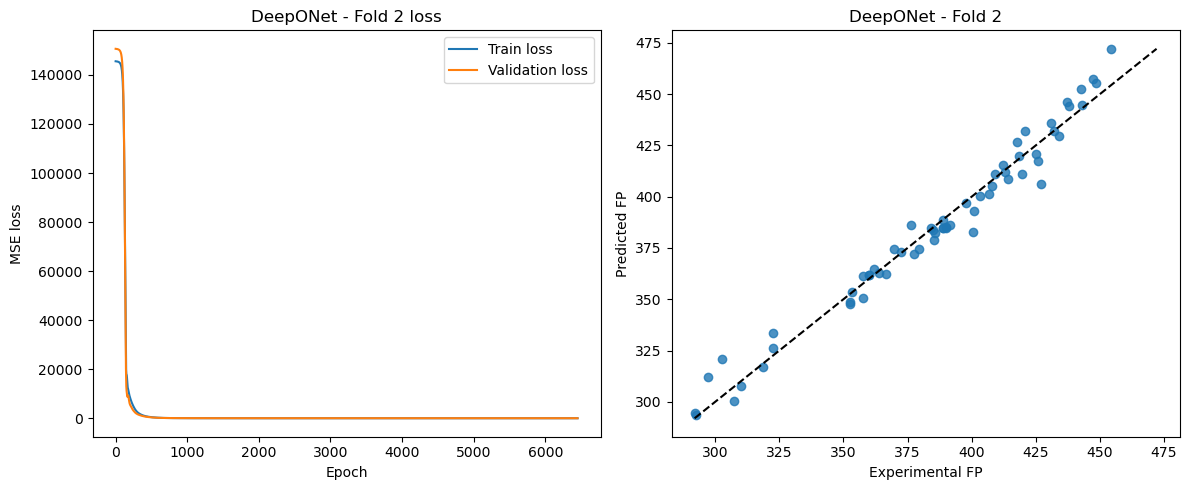

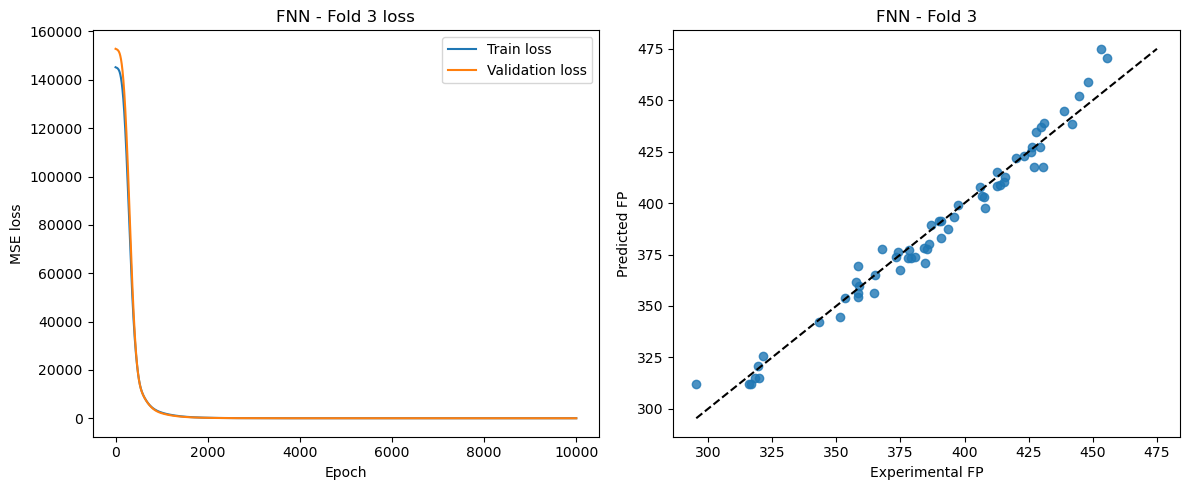

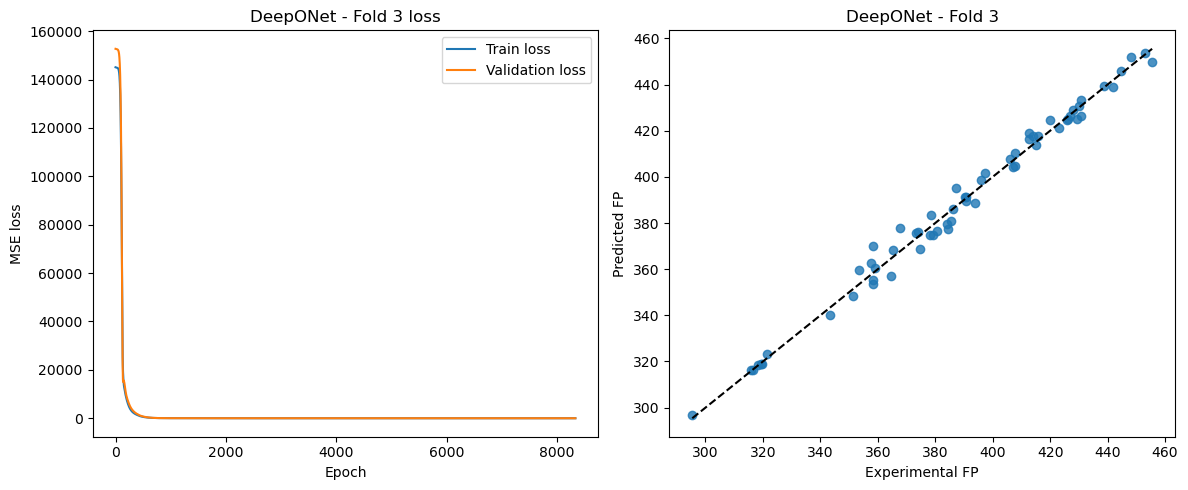

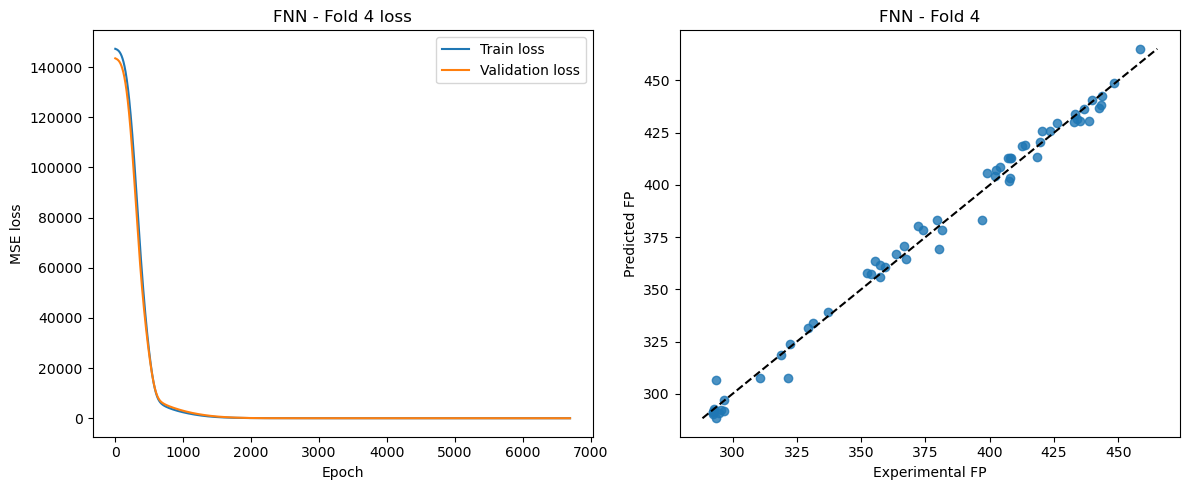

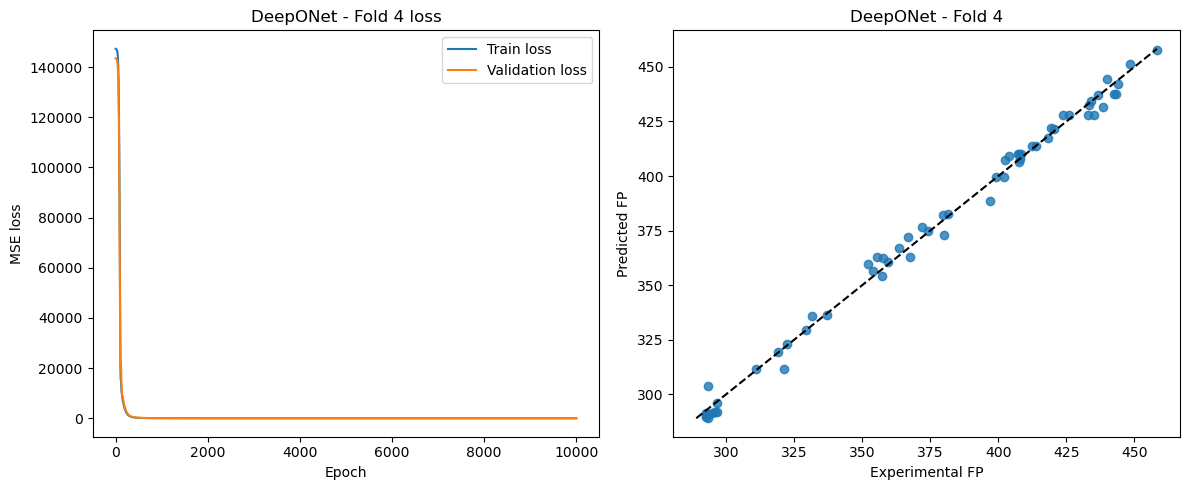

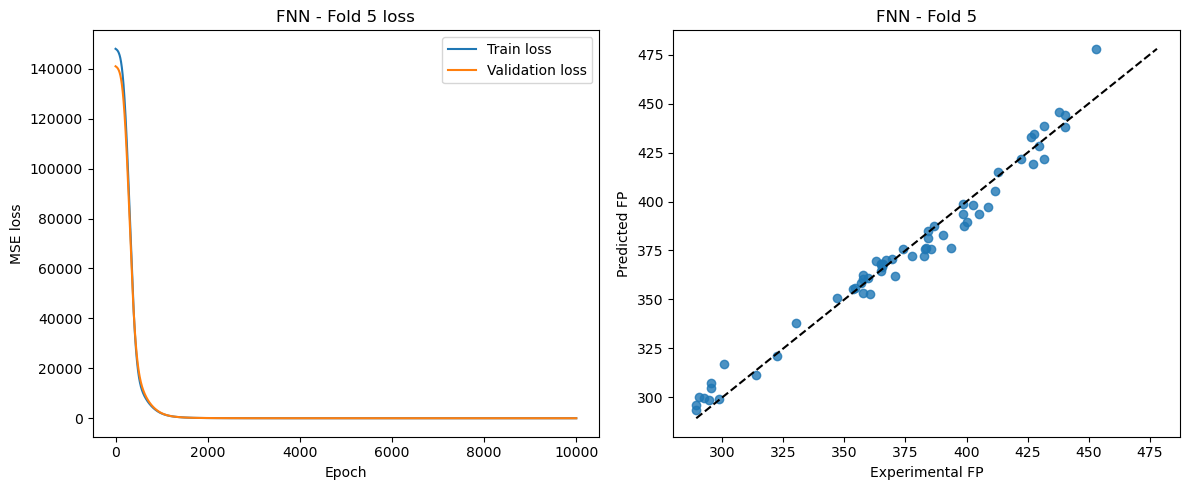

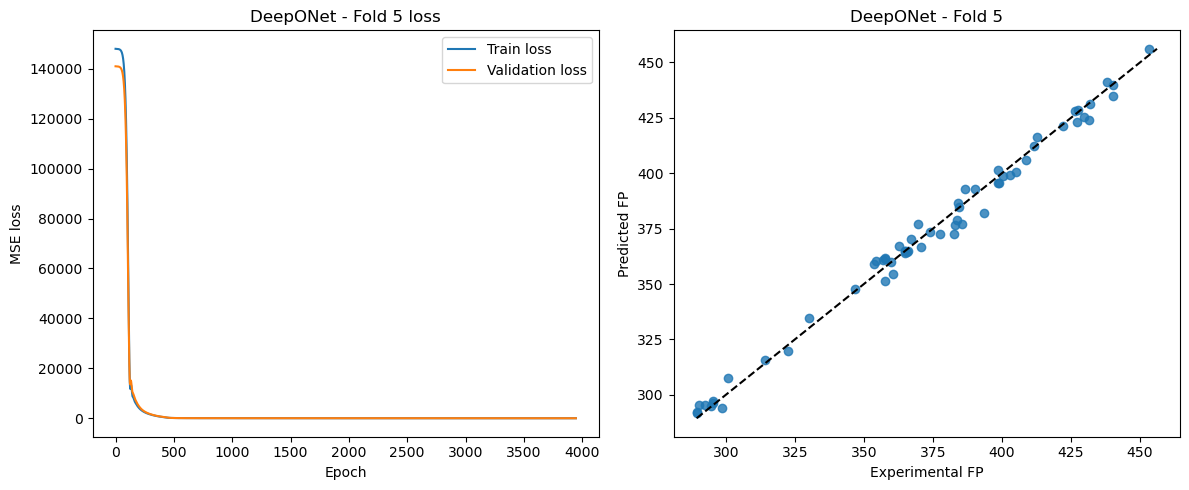

In [10]:
# KFold cross-validation
folds = 5
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

fnn_fold_metrics = []
deeponet_fold_metrics = []
deeponet_fold_artifacts = []
fold_predictions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(fnn_features), start=1):
    fnn_scaler = StandardScaler()
    branch_scaler = StandardScaler()
    trunk_scaler = StandardScaler()

    fnn_train = fnn_scaler.fit_transform(fnn_features[train_idx])
    fnn_val = fnn_scaler.transform(fnn_features[val_idx])
    branch_train = fit_transform_except_x1(branch_scaler, branch_features[train_idx])
    branch_val = transform_except_x1(branch_scaler, branch_features[val_idx])
    trunk_train = fit_transform_except_x1(trunk_scaler, trunk_features[train_idx])
    trunk_val = transform_except_x1(trunk_scaler, trunk_features[val_idx])

    fnn_train_tensor = torch.tensor(fnn_train, dtype=torch.float32).to(DEVICE)
    fnn_val_tensor = torch.tensor(fnn_val, dtype=torch.float32).to(DEVICE)
    branch_train_tensor = torch.tensor(branch_train, dtype=torch.float32).to(DEVICE)
    branch_val_tensor = torch.tensor(branch_val, dtype=torch.float32).to(DEVICE)
    trunk_train_tensor = torch.tensor(trunk_train, dtype=torch.float32).to(DEVICE)
    trunk_val_tensor = torch.tensor(trunk_val, dtype=torch.float32).to(DEVICE)
    y_train_tensor = (
        torch.tensor(fp_values[train_idx], dtype=torch.float32).unsqueeze(1).to(DEVICE)
    )
    y_val_tensor = (
        torch.tensor(fp_values[val_idx], dtype=torch.float32).unsqueeze(1).to(DEVICE)
    )

    fnn_model = FNN(input_dim=fnn_train_tensor.shape[1], output_dim=1).to(DEVICE)
    fnn_train_losses, fnn_val_losses, fnn_val_predictions = train_fnn_fold(
        fnn_model,
        fnn_train_tensor,
        y_train_tensor,
        fnn_val_tensor,
        y_val_tensor,
        study_fnn.best_params["lr"],
    )
    fnn_metrics = compute_metrics(fnn_val_predictions, y_val_tensor)
    fnn_metrics["fold"] = fold_idx
    fnn_fold_metrics.append(fnn_metrics)
    plot_fold_results(
        "FNN",
        fold_idx,
        fnn_train_losses,
        fnn_val_losses,
        y_val_tensor,
        fnn_val_predictions,
    )

    deeponet_model = DeepONet(
        branch_dim=branch_train_tensor.shape[1],
        trunk_dim=trunk_train_tensor.shape[1],
        output_dim=1,
    ).to(DEVICE)
    deeponet_train_losses, deeponet_val_losses, deeponet_val_predictions = (
        train_deeponet_fold(
            deeponet_model,
            branch_train_tensor,
            trunk_train_tensor,
            y_train_tensor,
            branch_val_tensor,
            trunk_val_tensor,
            y_val_tensor,
            study_deeponet.best_params["lr"],
        )
    )
    deeponet_metrics = compute_metrics(deeponet_val_predictions, y_val_tensor)
    deeponet_metrics["fold"] = fold_idx
    deeponet_fold_metrics.append(deeponet_metrics)
    deeponet_fold_artifacts.append(
        {
            "fold": fold_idx,
            "model_state_dict": copy.deepcopy(deeponet_model.state_dict()),
            "branch_scaler": branch_scaler,
            "trunk_scaler": trunk_scaler,
            "rmse (K)": deeponet_metrics["rmse (K)"],
        }
    )
    plot_fold_results(
        "DeepONet",
        fold_idx,
        deeponet_train_losses,
        deeponet_val_losses,
        y_val_tensor,
        deeponet_val_predictions,
    )

    fold_predictions.append(
        {
            "fold": fold_idx,
            "y_true": y_val_tensor.detach().cpu().numpy().ravel(),
            "fnn_predictions": fnn_val_predictions.detach().cpu().numpy().ravel(),
            "deeponet_predictions": deeponet_val_predictions.detach()
            .cpu()
            .numpy()
            .ravel(),
        }
    )


## Models Benchmarking

In [11]:
# Feedforward metrics
fnn_metrics_df = pd.DataFrame(fnn_fold_metrics)
mean_fnn_metrics = fnn_metrics_df.drop(columns=["fold"]).mean()

display(fnn_metrics_df)
print(mean_fnn_metrics)

,mae (K),rmse (K),mape,r2,fold
0,5.687402,7.660510,0.015628,0.973089,1
1,5.067191,7.033456,0.013357,0.972492,2
2,5.373329,6.924895,0.013793,0.967639,3
3,4.099830,5.149271,0.011064,0.990366,4
4,5.840070,7.468149,0.015813,0.971381,5


mae (K)     5.213564
rmse (K)    6.847256
mape        0.013931
r2          0.974993
dtype: float64


In [12]:
# DeepONet metrics
deeponet_metrics_df = pd.DataFrame(deeponet_fold_metrics)
mean_deeponet_metrics = deeponet_metrics_df.drop(columns=["fold"]).mean()

display(deeponet_metrics_df)
print(mean_deeponet_metrics)

,mae (K),rmse (K),mape,r2,fold
0,3.299917,5.126093,0.009119,0.987950,1
1,5.560703,7.261574,0.014494,0.970679,2
2,3.207721,4.011944,0.008311,0.989138,3
3,3.143508,4.054756,0.008629,0.994026,4
4,3.472713,4.289581,0.009417,0.990558,5


mae (K)     3.736913
rmse (K)    4.948790
mape        0.009994
r2          0.986470
dtype: float64


### 1-Butanol + FAEEs Evaluation

Reading the data into a `pandas.DataFrame`:

In [13]:
but_faee_data = pd.read_csv(DATA_PATH / "processed" / "butanol_faee_data.csv")

display(but_faee_data)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method
0,Ethyl Octanoate,NaN,1.00,0.00,172.26460,3.074711,0
1,Butanol,Ethyl Octanoate,0.05,0.95,167.35750,4.171576,0
2,Butanol,Ethyl Octanoate,0.10,0.90,162.45030,4.682051,0
3,Butanol,Ethyl Octanoate,0.15,0.85,157.54320,5.018373,0
4,Butanol,Ethyl Octanoate,0.20,0.80,152.63600,5.269604,0
...,...,...,...,...,...,...,...
100,Butanol,Ethyl Myristate,0.80,0.20,110.58210,6.562587,0
101,Butanol,Ethyl Myristate,0.85,0.15,101.46700,6.623210,0
102,Butanol,Ethyl Myristate,0.90,0.10,92.35185,6.680367,0
103,Butanol,Ethyl Myristate,0.95,0.05,83.23673,6.734432,0


Select the best DeepONet fold and restore its fitted scalers:

In [14]:
best_deeponet_artifact = min(
    deeponet_fold_artifacts, key=lambda artifact: artifact["rmse (K)"]
)

best_deeponet_model = DeepONet(
    branch_dim=branch_features.shape[1],
    trunk_dim=trunk_features.shape[1],
    output_dim=1,
).to(DEVICE)
best_deeponet_model.load_state_dict(best_deeponet_artifact["model_state_dict"])
best_deeponet_model.eval()

branch_scaler = best_deeponet_artifact["branch_scaler"]
trunk_scaler = best_deeponet_artifact["trunk_scaler"]

print(f"Using DeepONet fold {best_deeponet_artifact['fold']} for inference")

Using DeepONet fold 3 for inference


Process the DataFrame using the DeepONet branch (`x_1`, `lnPvap`) and trunk (`x_1`, `MM`) inputs:

In [15]:
but_faee_branch_features = but_faee_data[["x_1", "lnPvap"]].values
but_faee_trunk_features = but_faee_data[["x_1", "MM"]].values

but_faee_branch_scaled = transform_except_x1(branch_scaler, but_faee_branch_features)
but_faee_trunk_scaled = transform_except_x1(trunk_scaler, but_faee_trunk_features)

but_faee_branch_tensor = torch.tensor(but_faee_branch_scaled, dtype=torch.float32).to(
    DEVICE
)
but_faee_trunk_tensor = torch.tensor(but_faee_trunk_scaled, dtype=torch.float32).to(
    DEVICE
)

with torch.no_grad():
    but_faee_pred = best_deeponet_model(but_faee_branch_tensor, but_faee_trunk_tensor)

but_faee_predictions = but_faee_data.copy()
but_faee_predictions["predicted_FP"] = but_faee_pred.detach().cpu().numpy().ravel()

display(but_faee_predictions)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method,predicted_FP
0,Ethyl Octanoate,NaN,1.00,0.00,172.26460,3.074711,0,355.132812
1,Butanol,Ethyl Octanoate,0.05,0.95,167.35750,4.171576,0,344.510773
2,Butanol,Ethyl Octanoate,0.10,0.90,162.45030,4.682051,0,338.269562
3,Butanol,Ethyl Octanoate,0.15,0.85,157.54320,5.018373,0,334.240936
4,Butanol,Ethyl Octanoate,0.20,0.80,152.63600,5.269604,0,331.293915
...,...,...,...,...,...,...,...,...
100,Butanol,Ethyl Myristate,0.80,0.20,110.58210,6.562587,0,317.923126
101,Butanol,Ethyl Myristate,0.85,0.15,101.46700,6.623210,0,317.370239
102,Butanol,Ethyl Myristate,0.90,0.10,92.35185,6.680367,0,316.860870
103,Butanol,Ethyl Myristate,0.95,0.05,83.23673,6.734432,0,316.390381


Plot predicted FP values as a function of `x_1` for each binary system:

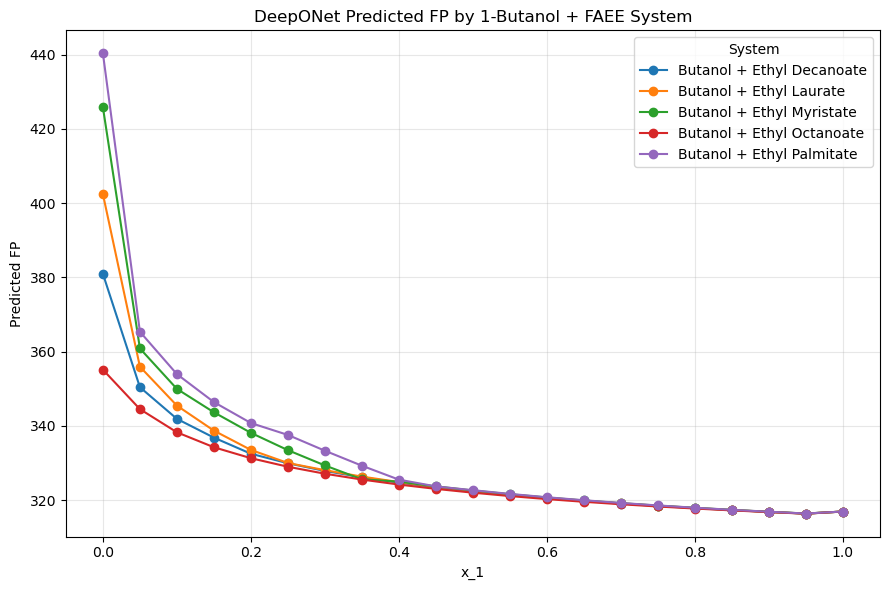

In [16]:
binary_system_predictions = but_faee_predictions.loc[
    but_faee_predictions["substance_2"].notna()
    & (but_faee_predictions["substance_2"] != "")
].copy()
pure_component_predictions = but_faee_predictions.loc[
    but_faee_predictions["substance_2"].isna()
    | (but_faee_predictions["substance_2"] == "")
].copy()
pure_butanol_prediction = pure_component_predictions.loc[
    pure_component_predictions["substance_1"] == "Butanol"
].iloc[0]

plt.figure(figsize=(9, 6))
for ester_name, system_data in binary_system_predictions.groupby("substance_2"):
    pure_ester_prediction = pure_component_predictions.loc[
        pure_component_predictions["substance_1"] == ester_name
    ].iloc[0]
    system_data = system_data.copy()
    system_data["plot_x_1"] = system_data["x_1"]
    system_data = pd.concat(
        [
            pd.DataFrame(
                {
                    "plot_x_1": [0.0],
                    "predicted_FP": [pure_ester_prediction["predicted_FP"]],
                }
            ),
            system_data[["plot_x_1", "predicted_FP"]],
            pd.DataFrame(
                {
                    "plot_x_1": [1.0],
                    "predicted_FP": [pure_butanol_prediction["predicted_FP"]],
                }
            ),
        ],
        ignore_index=True,
    ).sort_values("plot_x_1")
    plt.plot(
        system_data["plot_x_1"],
        system_data["predicted_FP"],
        marker="o",
        label=f"Butanol + {ester_name}",
    )

plt.xlabel("x_1")
plt.ylabel("Predicted FP")
plt.title("DeepONet Predicted FP by 1-Butanol + FAEE System")
plt.legend(title="System")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()